## Modellvergleich & Evaluation

Ziel des Notebooks
- Vergleich von drei Modellen
    - Random Forest
    - Random Forest mit log-transformierter Zielvariable
    - XGBoost mit log-transfomierter Zielvariable
- Auswahl des besten Modells
- Feature Importance des besten Modells
- Fehleranalyse (Residuals)

In [1]:
# Imports & Setup

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats


sns.set_theme(style="whitegrid", font_scale=1.2) # Darstellung optimieren


In [2]:
# Daten und Modelle laden

# Vorhersagen laden
paths = {
    "rf": "../models/predictions_rf.csv",
    "rf_log": "../models/predictions_rf_log.csv",
    "xgb_log": "../models/predictions_xgb_log.csv"
}

predictions = {}

for name, path in paths.items():
    try:
        predictions[name] = pd.read_csv(path)
        print(f"Vorhersagen geladen: {name} ({path}) – {len(predictions[name])} Zeilen")
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {path}")


# Modelle laden (nur wenn benötigt)

def load_model(path):
    try:
        model = joblib.load(path)
        print(f"Modell geladen: {path}")
        return model
    except FileNotFoundError:
        print(f"Modell nicht gefunden: {path}")
        return None

rf_model = load_model("../models/rf_pipeline.pkl")
rf_log_model = load_model("../models/rf_log_pipeline.pkl")
xgb_log_model = load_model("../models/xgb_log_pipeline.pkl")



Vorhersagen geladen: rf (../models/predictions_rf.csv) – 1000 Zeilen
Vorhersagen geladen: rf_log (../models/predictions_rf_log.csv) – 1000 Zeilen
Vorhersagen geladen: xgb_log (../models/predictions_xgb_log.csv) – 1000 Zeilen
Modell geladen: ../models/rf_pipeline.pkl
Modell geladen: ../models/rf_log_pipeline.pkl
Modell geladen: ../models/xgb_log_pipeline.pkl


In [3]:
# Metriken für alle Modelle berechnen

def evaluate_models(df, model_name):
    """
    Erwartetet einen DataFrame mit den Spalten 'y_true' und 'y_pred'.
    Gibt ein Dictionary mit RMSE, MAE und R² und Modellnamen zurück.
    """
    y_true = df['y_true']
    y_pred = df['y_pred']
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "n_samples": len(df)
    }

results = []

# Mapping der Modellnamen für bessere Lesbarkeit
name_map = {
    "rf": "RandomForest",
    "rf_log": "RandomForest (Log)",
    "xgb_log": "XGBoost (Log)"
}

for key, df_pred in predictions.items():
    if df_pred is None:
        continue
    res = evaluate_models(df_pred, name_map.get(key, key))
    results.append(res)

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df[["model", "RMSE", "MAE", "R²", "n_samples"]]
metrics_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R²": "{:.3f}",
    "n_samples": "{:d}"
})

,model,RMSE,MAE,R²,n_samples
0,RandomForest,68.20,47.26,0.349,1000
1,RandomForest (Log),68.30,45.33,0.347,1000
2,XGBoost (Log),68.08,44.84,0.351,1000


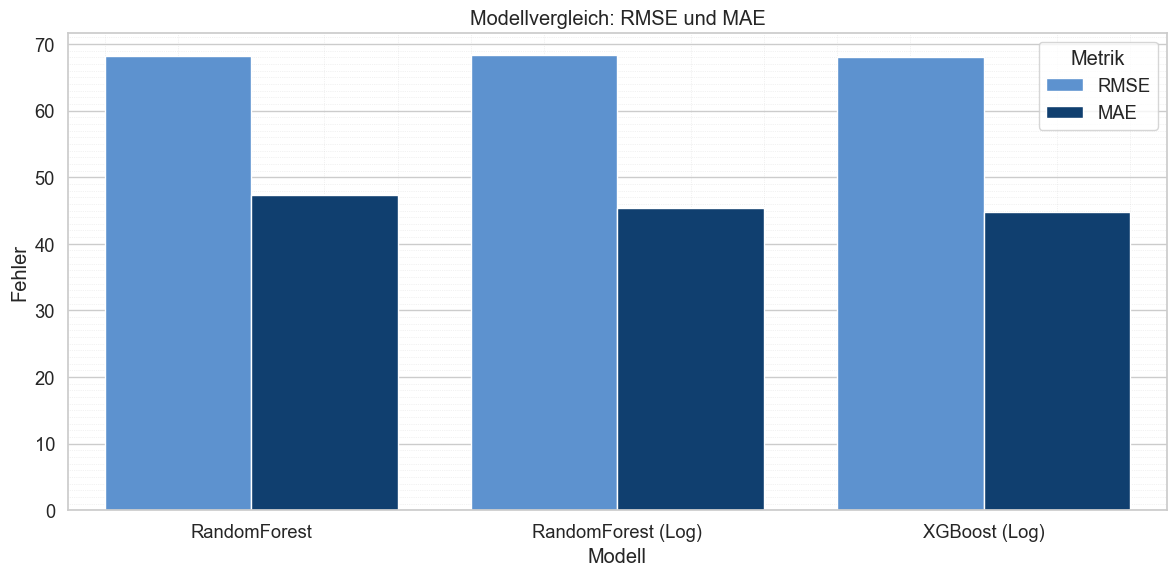

In [4]:
# Modellvergleich (RMSE und MAE)

# Spalten mit relevanten Metriken
error_metrics = metrics_df[["model", "RMSE", "MAE"]]

# Long-Format für Seaborn
error_long = error_metrics.melt(
    id_vars="model", 
    value_vars=["RMSE", "MAE"],
    var_name="metric", 
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(data=error_long, 
            x="model", 
            y="value", 
            hue="metric", 
            palette=["#4A90E2", "#003f7f"]
)

plt.title("Modellvergleich: RMSE und MAE")
plt.ylabel("Fehler")
plt.xlabel("Modell")
plt.legend(title="Metrik")

plt.gca().minorticks_on()
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

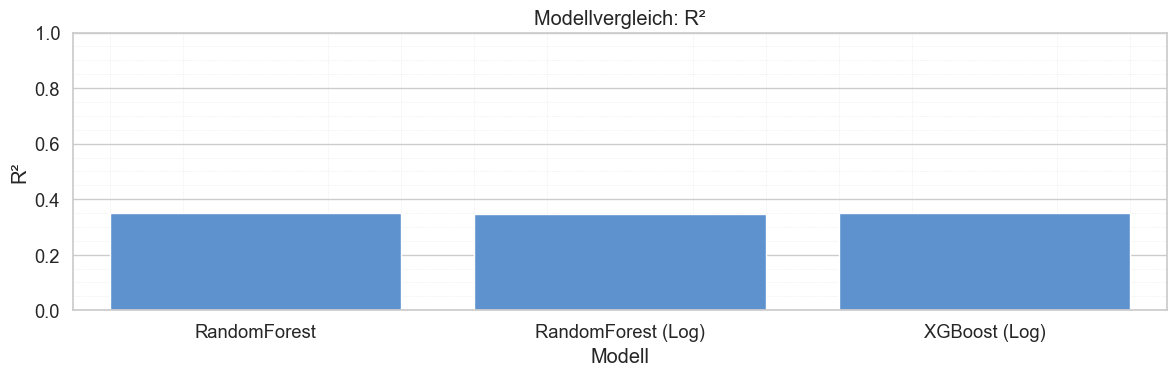

In [5]:
# Modellvergleich (R²)

r2_metrics = metrics_df[["model", "R²"]]

plt.figure(figsize=(12, 4))
sns.barplot(data=r2_metrics, x="model", y="R²", color="#4A90E2")
plt.title("Modellvergleich: R²")
plt.ylabel("R²")
plt.xlabel("Modell")
plt.ylim(0, 1)

ax = plt.gca()
ax.minorticks_on()
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
# Bestes Modell anhand RMSE auswählen

best_row = metrics_df.loc[metrics_df['RMSE'].idxmin()]
best_model_name = best_row['model']

# Mapping zu Modellobjekten
model_map = {
    "Random Forest": rf_model,
    "Random Forest (Log)": rf_log_model,
    "XGBoost (Log)": xgb_log_model
}

# Bestes Modellobjekt zuweisen
best_model = model_map[best_model_name]
print(f"Bestes Modell: {best_model_name} mit RMSE = {best_row['RMSE']:.2f}")

# Mapping zu Vorhersage-Dateien
pred_file_map = {
    "Random Forest": "../models/predictions_rf.csv",
    "Random Forest (Log)": "../models/predictions_rf_log.csv",
    "XGBoost (Log)": "../models/predictions_xgb_log.csv"
}

# Vorhersagen des besten Modells kennzeichnen
best_pred_file = pred_file_map[best_model_name]
print(f"Vorhersagen des besten Modells aus: {best_pred_file}")

best_pred_df = pd.read_csv(best_pred_file)
print(f"Vorhersagen als DataFrame geladen: {len(best_pred_df)} Zeilen")




Bestes Modell: XGBoost (Log) mit RMSE = 68.08
Vorhersagen des besten Modells aus: ../models/predictions_xgb_log.csv
Vorhersagen als DataFrame geladen: 1000 Zeilen


In [7]:
# Feature Importance analysieren

# Feature-Namen extrahieren

preprocess = best_model.named_steps["preprocess"]
print(preprocess.transformers_)

# Numerische Features
num_features = preprocess.transformers_[0][2]

# Kategorische Features (OneHotEncoder)
cat_pipeline = preprocess.transformers_[1][1]
onehot = cat_pipeline.named_steps["onehot"]
cat_features = onehot.get_feature_names_out(preprocess.transformers_[1][2])

# Gesamte Feature-Liste erstellen
feature_names = list(num_features) + list(cat_features)

print(f"Anzahl Features nach OneHot-Encoding: {len(feature_names)}")

[('num', Pipeline(steps=[('scaler', StandardScaler())]), ['minimum_nights', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'amenity_count']), ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), ['neighbourhood', 'room_type'])]
Anzahl Features nach OneHot-Encoding: 25


In [8]:
# Feature Importance aus XGB holen
xgb = best_model.named_steps["model"]
importances = xgb.feature_importances_
print(f"Anzahl Feature Importances: {len(importances)}")

# Feature Importances mit Namen kombinieren
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(20))

Anzahl Feature Importances: 25
                                     Feature  Importance
6             neighbourhood_I Centro Storico    0.535681
21                 room_type_Entire home/apt    0.080955
11     neighbourhood_V Prenestino/Centocelle    0.055265
23                    room_type_Private room    0.033686
18                neighbourhood_XIII Aurelia    0.030314
24                     room_type_Shared room    0.028923
4                                  longitude    0.025205
3                                   latitude    0.020824
7         neighbourhood_II Parioli/Nomentano    0.017596
1                          number_of_reviews    0.016519
12         neighbourhood_VI Roma delle Torri    0.015469
5                              amenity_count    0.013828
17             neighbourhood_XII Monte Verde    0.013306
2                       review_scores_rating    0.012179
13  neighbourhood_VII San Giovanni/Cinecittà    0.010685
14           neighbourhood_VIII Appia Antica    0.010547


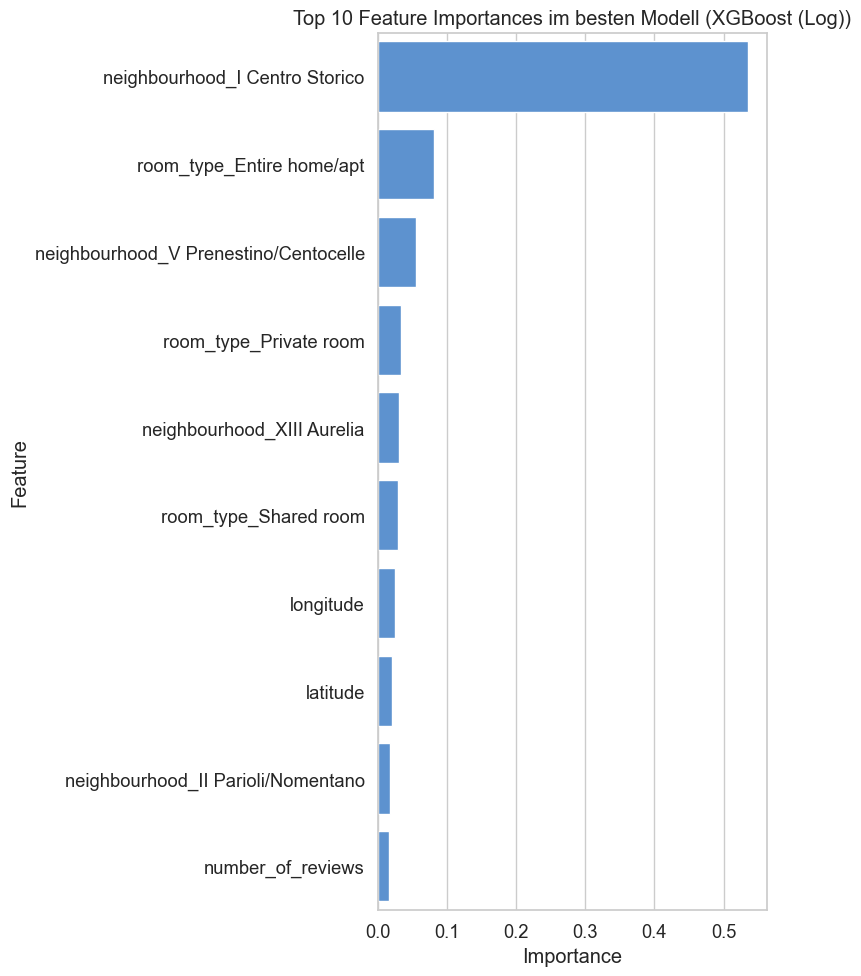

In [9]:
# Feature Importances visualisieren (Top n)

top_n = 10
plt.figure(figsize=(8, 10))

sns.barplot(
    data=feature_importance_df.head(top_n), 
    x="Importance", 
    y="Feature", 
    color="#4A90E2"
)
plt.title(f"Top {top_n} Feature Importances im besten Modell ({best_model_name})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

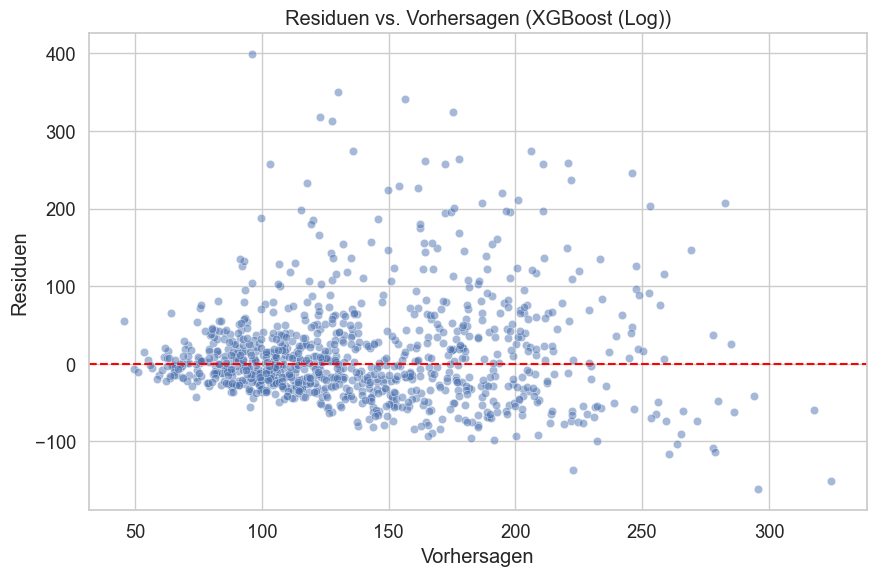

In [10]:
# Residuen analysieren

# Residuen berechnen
best_pred_df["residuals"] = best_pred_df["y_true"] - best_pred_df["y_pred"] 

# Residuen vs. Vorhersagen

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=best_pred_df, 
    x="y_pred", 
    y="residuals",
    alpha=0.5
)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuen vs. Vorhersagen ({best_model_name})")
plt.xlabel("Vorhersagen")
plt.ylabel("Residuen")
plt.tight_layout()
plt.show()


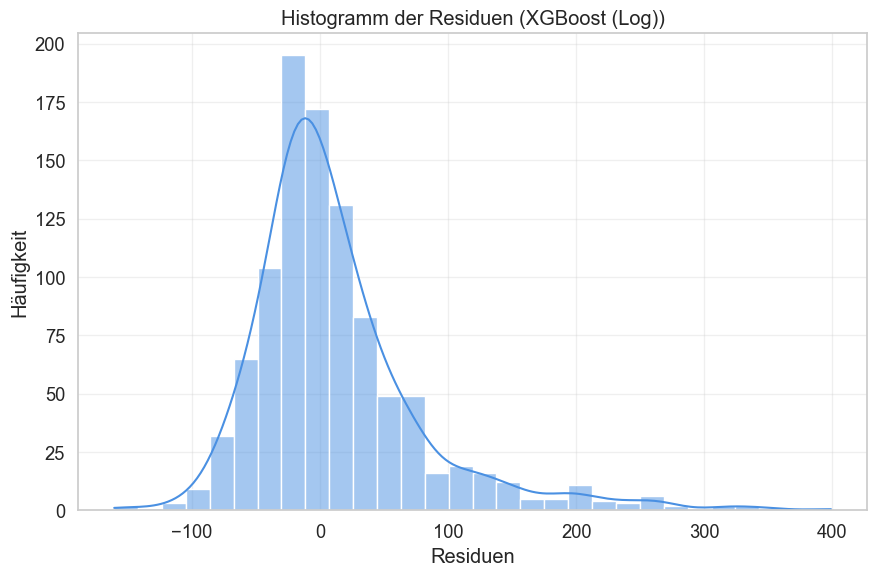

In [11]:
# Histogramm der Residuen

plt.figure(figsize=(9, 6))
sns.histplot(best_pred_df["residuals"], bins=30, kde=True, color="#4A90E2")
plt.title(f"Histogramm der Residuen ({best_model_name})")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

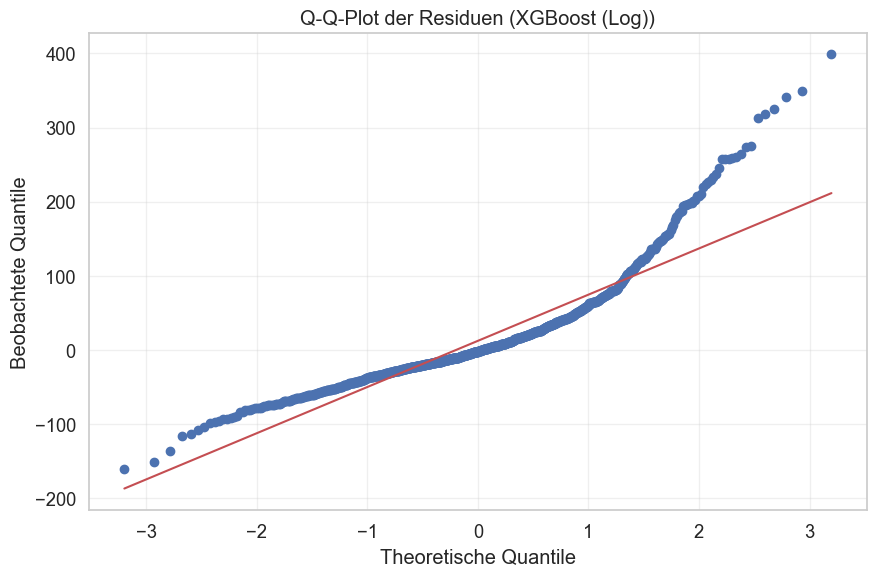

In [12]:
# Q-Q-Plot der Residuen

plt.figure(figsize=(9, 6))
stats.probplot(best_pred_df["residuals"], dist="norm", plot=plt)
plt.title(f"Q-Q-Plot der Residuen ({best_model_name})")
plt.xlabel("Theoretische Quantile")
plt.ylabel("Beobachtete Quantile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# RSME nach Preis-Qantilen

best_pred_df["price_quantile"] = pd.qcut(best_pred_df["y_true"], q=5, labels= ["q1", "q2", "q3", "q4", "q5"])  
rsme_by_quantile = best_pred_df.groupby("price_quantile", observed=False).apply(
    lambda df: np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])), include_groups=False
) 

rsme_by_quantile

price_quantile
q1     33.107746
q2     34.205744
q3     35.945640
q4     45.917019
q5    132.652522
dtype: float64

## Fazit

- Modellvergleich
    - Qualität der betrachteten Modelle sehr ähnlich
    - XGBoost mit log-transformierter Zielvariable ist (gemessen an RMSE) das beste Modell
- Feature Importance
    - Zentrumsnahe Lage wichtigster Preistreiber
    - Unterkunftsmerkmale von untergeordneter Bedeutung (Ausnahme: private vs. geteilte Unterkünfte)
    - Bei Bewertungen ist die Anzahl unter den wichtigsten Features vertreten, während die Bewertung selbst nicht enthalten ist
    - Anzahl der Austattungsmerkmale nicht unter den wichtigsten Features zu finden
- Fehleranalyse
    - Residuen näherungsweise normalverteilt, allerdings rechts "fat tails" erkennbar
    - Während Modell im niedrigen bis mittleren Preisbereich solide funktioniert, weist es im höheren Preisbereich sichtbare Schwächen auf
- Erweiterungen
    - Zusätzliche Features extrahieren (z. B. konkrete Ausstattungsmerkmale), insb. mit Blick auf die Prognose höherpreisiger Unterkünfte
    - Methoden anwenden, die auf kategoriale Variablen (z. B. catboost) oder verschiedene Preisbereiche spezialisiert sind (z. B. Mix-of-Experts)



Nächste Schritte:
- Fehleranalyse des besten Modells
    - RSME nach Preis-Quantilen visualisieren
    - Fazit ziehen
        - Modell in Ordnung jedoch mit Schwächen in den oberen Preisbereichen
            - Weitere Features extrahieren (z. B. mit catboost)
            - Mix-of-Experts-Ansatz
- Skripte anlegen
- Feinschliff
    - README
    - requirements.txt
    - notebook glattziehen und für Github vorbereiten
    - sauber git commits